In [1]:
import sys

print(sys.executable)

/Users/clutchyy/Documents/credit-card-fraud-detection/venv/bin/python3


In [2]:
import pandas
import numpy
import matplotlib
import seaborn
import sklearn
import imblearn
import joblib

print("Everything is working!")

Everything is working!


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

import joblib

print("Project libraries imported successfully!")

Project libraries imported successfully!


In [4]:
df = pd.read_csv("../data/creditcard.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 284807
Number of columns: 31


In [7]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [9]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


In [12]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [13]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


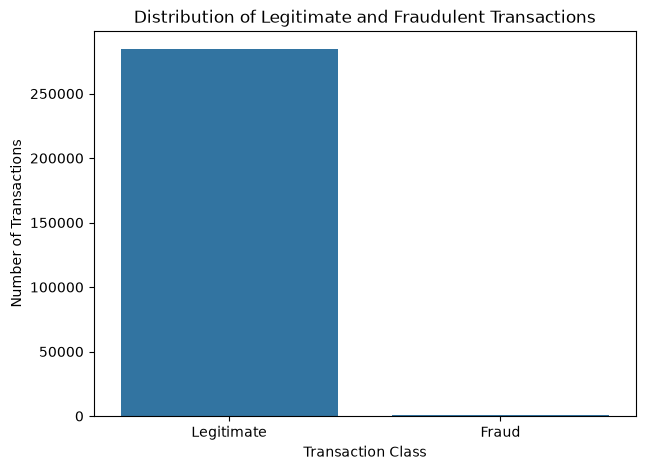

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

In [15]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicate_rows))

print("\nClass distribution among duplicate rows:")
print(duplicate_rows["Class"].value_counts())

Total duplicate rows: 1854

Class distribution among duplicate rows:
Class
0    1822
1      32
Name: count, dtype: int64


In [16]:
print("Number of unique duplicate groups:")
print(duplicate_rows.drop_duplicates().shape[0])

Number of unique duplicate groups:
773


In [17]:
print("Transaction Amount Statistics:")
print(df["Amount"].describe())

Transaction Amount Statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [18]:
print("Legitimate transaction amounts:")
print(df[df["Class"] == 0]["Amount"].describe())

print("\nFraudulent transaction amounts:")
print(df[df["Class"] == 1]["Amount"].describe())

Legitimate transaction amounts:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraudulent transaction amounts:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


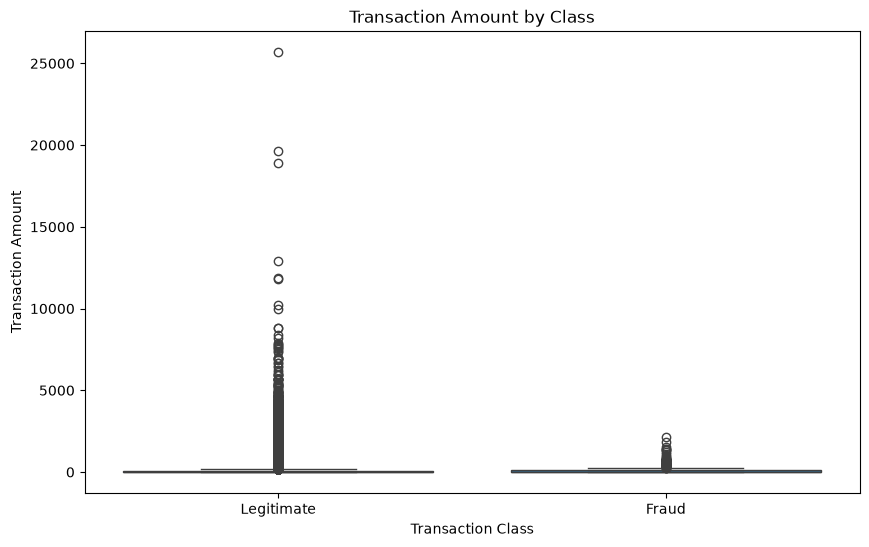

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

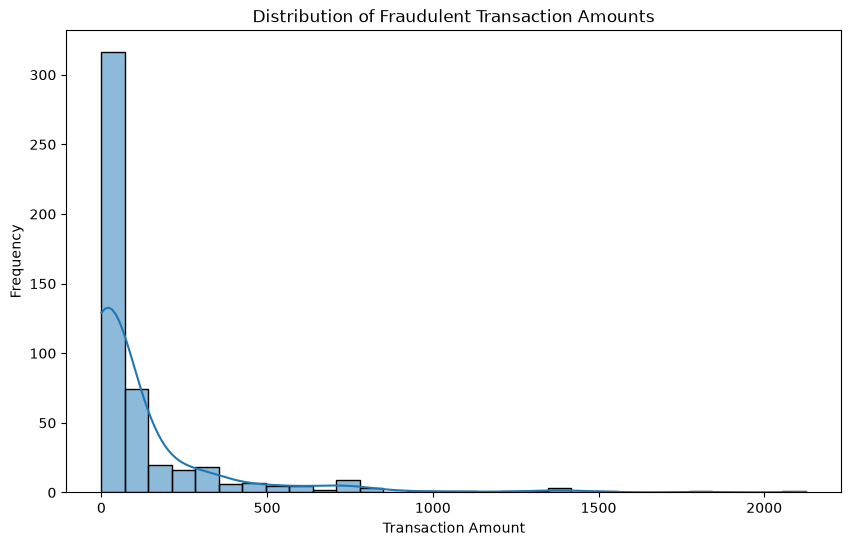

In [20]:
fraud_df = df[df["Class"] == 1]

plt.figure(figsize=(10, 6))

sns.histplot(
    fraud_df["Amount"],
    bins=30,
    kde=True
)

plt.title("Distribution of Fraudulent Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [21]:
print(df["Time"].describe())

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


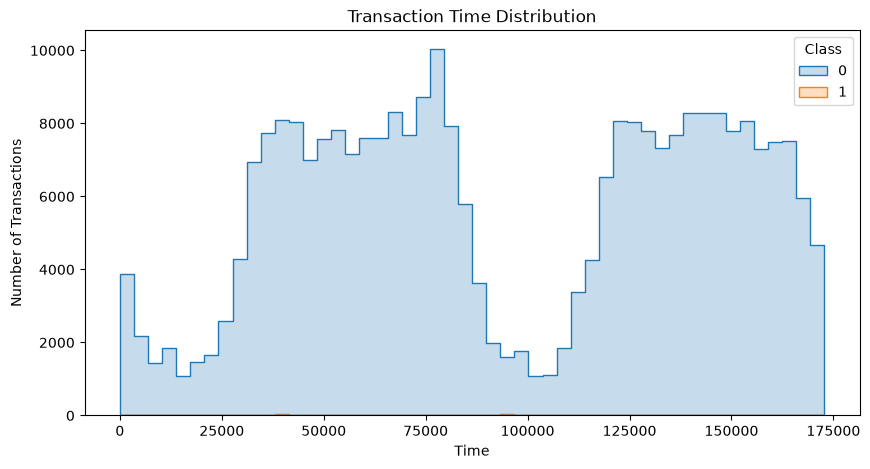

In [22]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=50,
    element="step"
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

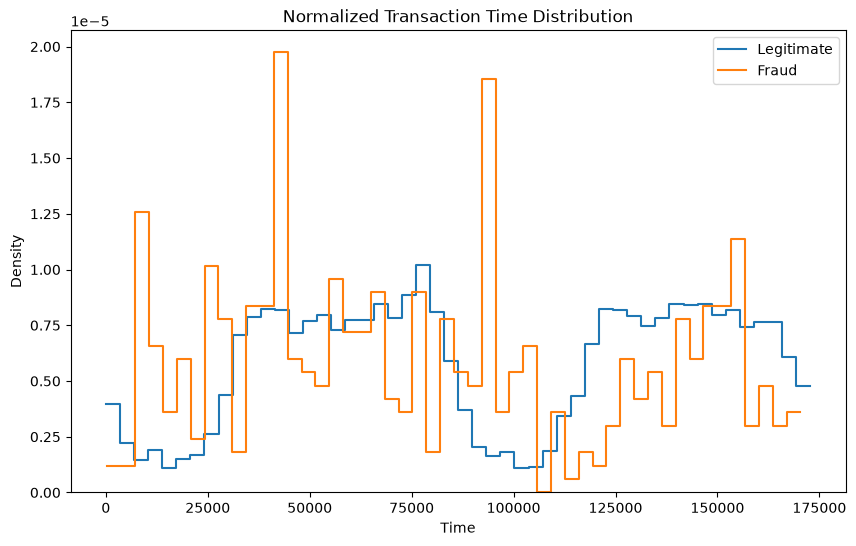

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df[df["Class"] == 0],
    x="Time",
    bins=50,
    stat="density",
    element="step",
    fill=False,
    label="Legitimate"
)

sns.histplot(
    data=df[df["Class"] == 1],
    x="Time",
    bins=50,
    stat="density",
    element="step",
    fill=False,
    label="Fraud"
)

plt.title("Normalized Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()

plt.show()

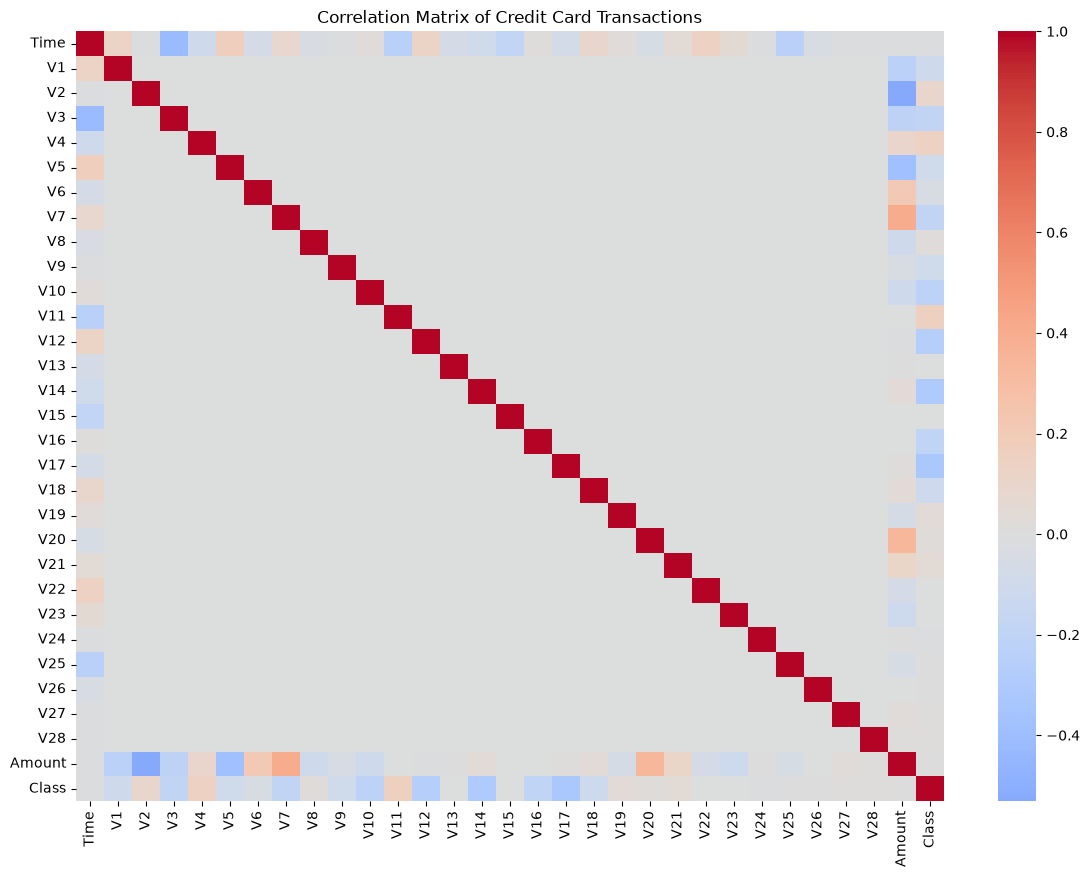

In [24]:
plt.figure(figsize=(14, 10))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Credit Card Transactions")
plt.show()

In [25]:
class_correlation = df.corr()["Class"].sort_values()

print(class_correlation)

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64


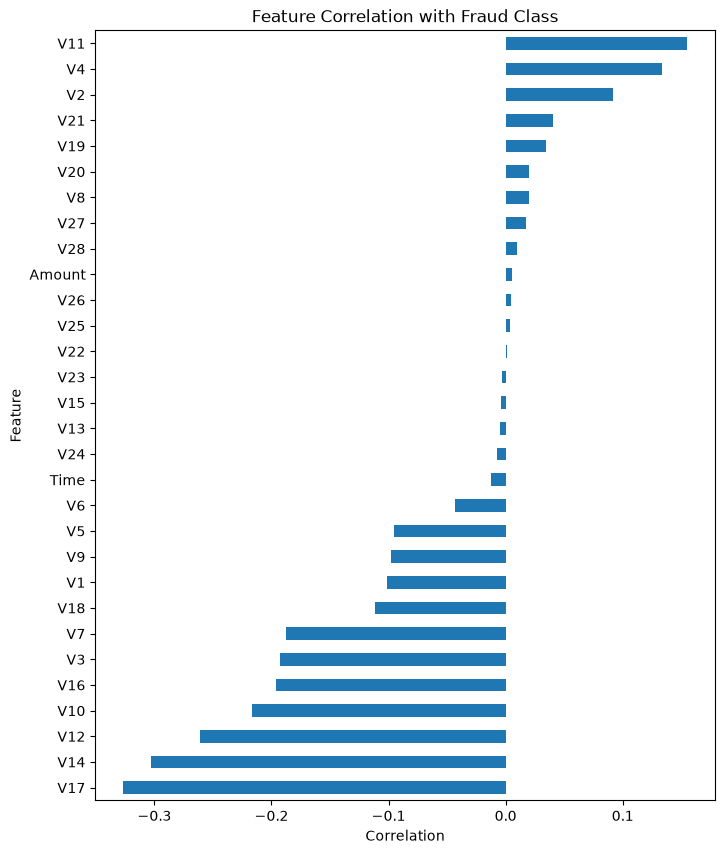

In [26]:
plt.figure(figsize=(8, 10))

class_correlation.drop("Class").plot(
    kind="barh"
)

plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled:", X_train_scaled.shape)
print("Testing data scaled:", X_test_scaled.shape)from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled:", X_train_scaled.shape)
print("Testing data scaled:", X_test_scaled.shape)

Training data scaled: (226980, 30)
Testing data scaled: (56746, 30)


Class
0    283253
1       473
Name: count, dtype: int64

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [29]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (283726, 30)
Target shape: (283726,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (226980, 30)
Testing set: (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled:", X_train_scaled.shape)
print("Testing data scaled:", X_test_scaled.shape)

Training data scaled: (226980, 30)
Testing data scaled: (56746, 30)


In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nTraining data after SMOTE:", X_train_smote.shape)

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64

Training data after SMOTE: (453204, 30)


In [34]:
# Import the models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Create models

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Models created successfully!")

Models created successfully!


In [35]:
# Train Logistic Regression

print("Training Logistic Regression...")
logistic_model.fit(X_train_smote, y_train_smote)

# Train Decision Tree

print("Training Decision Tree...")
decision_tree_model.fit(X_train_smote, y_train_smote)

# Train Random Forest

print("Training Random Forest...")
random_forest_model.fit(X_train_smote, y_train_smote)

print("\nAll models trained successfully!")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

All models trained successfully!


In [36]:
# Make predictions on the test set

y_pred_logistic = logistic_model.predict(X_test_scaled)
y_pred_tree = decision_tree_model.predict(X_test_scaled)
y_pred_forest = random_forest_model.predict(X_test_scaled)

print("Predictions generated successfully!")

Predictions generated successfully!


In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Function to evaluate a model

def evaluate_model(name, y_true, y_pred):
    print("=" * 50)
    print(name)
    print("=" * 50)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-Score :", f1_score(y_true, y_pred))
    print()


# Evaluate all three models

evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_logistic
)

evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_tree
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_forest
)

Logistic Regression
Accuracy : 0.9736721531033025
Precision: 0.053035143769968054
Recall   : 0.8736842105263158
F1-Score : 0.1

Decision Tree
Accuracy : 0.9974271314277658
Precision: 0.35260115606936415
Recall   : 0.6421052631578947
F1-Score : 0.4552238805970149

Random Forest
Accuracy : 0.9994889507630493
Precision: 0.9125
Recall   : 0.7684210526315789
F1-Score : 0.8342857142857143



In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Confusion matrices

cm_logistic = confusion_matrix(y_test, y_pred_logistic)
cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_forest = confusion_matrix(y_test, y_pred_forest)


print("Logistic Regression:")
print(cm_logistic)

print("\nDecision Tree:")
print(cm_tree)

print("\nRandom Forest:")
print(cm_forest)

Logistic Regression:
[[55169  1482]
 [   12    83]]

Decision Tree:
[[56539   112]
 [   34    61]]

Random Forest:
[[56644     7]
 [   22    73]]


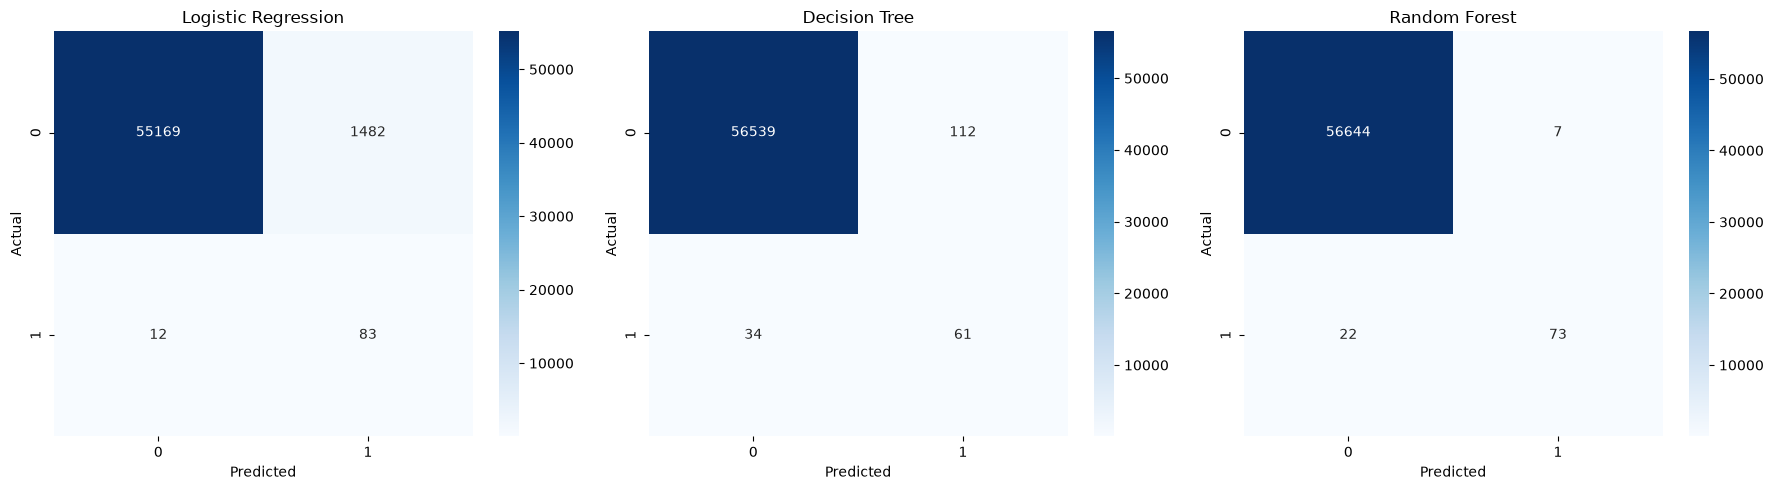

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Decision Tree
sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Random Forest
sns.heatmap(
    cm_forest,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[2]
)
axes[2].set_title("Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [40]:
# Model performance comparison

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_forest)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_forest)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_forest)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_forest)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.973672   0.053035  0.873684  0.100000
1        Decision Tree  0.997427   0.352601  0.642105  0.455224
2        Random Forest  0.999489   0.912500  0.768421  0.834286


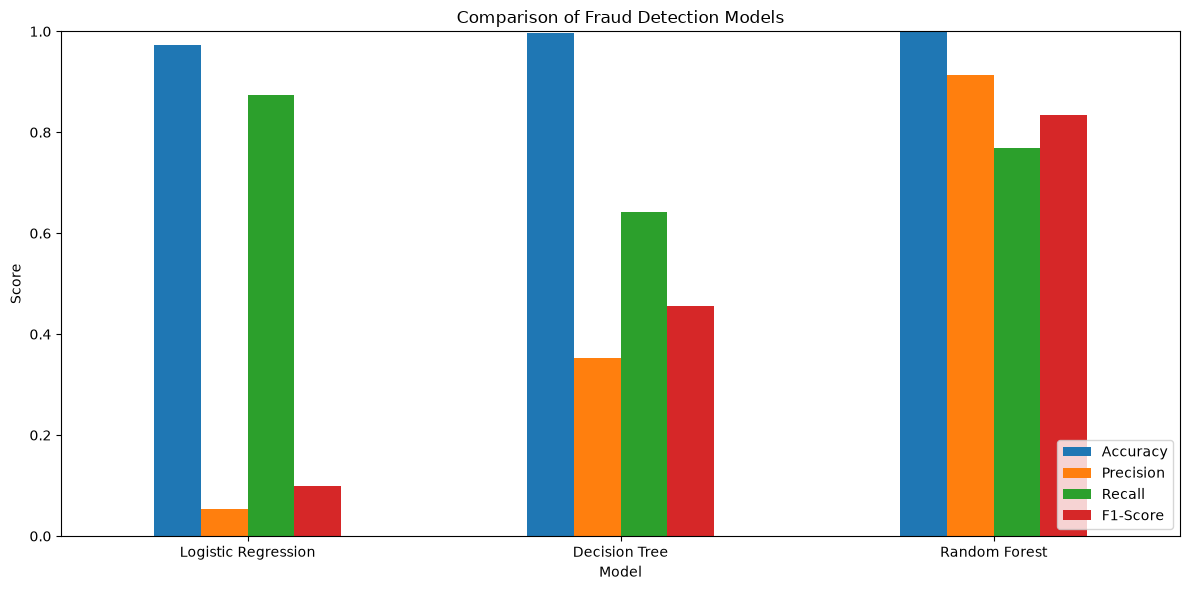

In [41]:
# Plot model comparison

results.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Fraud Detection Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [42]:
import joblib

# Save the trained Random Forest model
joblib.dump(random_forest_model, "random_forest_fraud_model.pkl")

# Save the scaler
joblib.dump(scaler, "fraud_scaler.pkl")

print("Random Forest model and scaler saved successfully!")

Random Forest model and scaler saved successfully!


In [43]:
def predict_transaction(transaction_data):

    # Convert input to DataFrame
    transaction_df = pd.DataFrame(
        [transaction_data],
        columns=X.columns
    )

    # Scale the transaction
    transaction_scaled = scaler.transform(transaction_df)

    # Make prediction
    prediction = random_forest_model.predict(transaction_scaled)[0]

    # Get probability
    probability = random_forest_model.predict_proba(transaction_scaled)[0]

    if prediction == 1:
        result = "FRAUDULENT TRANSACTION"
    else:
        result = "LEGITIMATE TRANSACTION"

    print("Prediction:", result)
    print("Fraud Probability:", round(probability[1] * 100, 2), "%")
    print("Legitimate Probability:", round(probability[0] * 100, 2), "%")

    return prediction

In [44]:
sample_transaction = X.iloc[0].values

predict_transaction(sample_transaction)

Prediction: LEGITIMATE TRANSACTION
Fraud Probability: 1.0 %
Legitimate Probability: 99.0 %


np.int64(0)

In [45]:
fraud_sample = X[y == 1].iloc[0].values

predict_transaction(fraud_sample)

Prediction: FRAUDULENT TRANSACTION
Fraud Probability: 55.0 %
Legitimate Probability: 45.0 %


np.int64(1)

# Conclusion

This project developed a machine learning based credit card fraud detection system.

The dataset was analyzed through exploratory data analysis, duplicate detection,
transaction amount analysis, transaction time analysis, correlation analysis,
and class distribution analysis.

Since fraudulent transactions represented only a very small proportion of the
dataset, SMOTE was applied to the training data to address class imbalance.

Three machine learning models were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

The models were evaluated using Accuracy, Precision, Recall and F1-Score.

Random Forest achieved an accuracy of approximately 99.95%, precision of 91.25%,
recall of 76.84%, and F1-score of 83.43% on the test dataset.

The results demonstrate that machine learning can be used to identify
potentially fraudulent credit card transactions while maintaining a low number
of false fraud alerts.

The trained Random Forest model can subsequently be saved and integrated into
a real-time fraud detection application.

In [47]:
# Final Model Summary

print("=" * 60)
print("CREDIT CARD FRAUD DETECTION - FINAL RESULTS")
print("=" * 60)

print("\nDataset:")
print("Total transactions after duplicate removal:", len(df))

print("\nClass Distribution:")
print("Legitimate transactions:", (y == 0).sum())
print("Fraudulent transactions:", (y == 1).sum())

print("\nRandom Forest Performance:")
print("Accuracy :", round(0.9994889507630493 * 100, 2), "%")
print("Precision:", round(0.9125 * 100, 2), "%")
print("Recall   :", round(0.7684210526315789 * 100, 2), "%")
print("F1-Score :", round(0.8342857142857143 * 100, 2), "%")

print("\nModel saved as:")
print("random_forest_fraud_model.pkl")

print("\nFraud detection system completed successfully!")

CREDIT CARD FRAUD DETECTION - FINAL RESULTS

Dataset:
Total transactions after duplicate removal: 283726

Class Distribution:
Legitimate transactions: 283253
Fraudulent transactions: 473

Random Forest Performance:
Accuracy : 99.95 %
Precision: 91.25 %
Recall   : 76.84 %
F1-Score : 83.43 %

Model saved as:
random_forest_fraud_model.pkl

Fraud detection system completed successfully!


In [48]:
import os

print("Model exists:", os.path.exists("random_forest_fraud_model.pkl"))
print("Scaler exists:", os.path.exists("fraud_scaler.pkl"))

Model exists: True
Scaler exists: True


In [49]:
import os

print("Model exists:", os.path.exists("random_forest_fraud_model.pkl"))
print("Scaler exists:", os.path.exists("fraud_scaler.pkl"))

Model exists: True
Scaler exists: True
